# Lista 12b — GQA: AG News Classification

Eksperymenty na trudniejszym benchmarku: **AG News** (4 klasy: Sport, Polityka, Biznes, Nauka).
Motywacja: wyniki na IMDB były płaskie — zadanie za proste. AG News ma 4 klasy i wymaga rozumienia tematu artykułu.

**Eksperymenty:**
1. Wpływ liczby głowic H w MHA (H=1,2,4,8) — baseline
2. MQA vs GQA vs MHA (G=1,2,4,8) — główny tradeoff

Modele zapisywane w folderze `models/`.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import time
import math
import random
import os
import socket
from collections import Counter, defaultdict
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Models dir: {os.path.abspath(MODELS_DIR)}')

Device: cuda
GPU: NVIDIA GeForce GTX 1080
VRAM: 8.6 GB
Models dir: /home/mikol/ai_studies/Deep-Neural-Networks-PWR/lab11/models


In [5]:
# MLflow setup z szybkim timeoutem
def mlflow_available(host='localhost', port=5002, timeout=2):
    try:
        socket.setdefaulttimeout(timeout)
        socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect((host, port))
        return True
    except Exception:
        return False

if mlflow_available():
    mlflow.set_tracking_uri('http://localhost:5002')
    print('MLflow: http://localhost:5002')
else:
    mlflow.set_tracking_uri('./mlruns')
    print('MLflow: lokalny folder ./mlruns')

mlflow.set_experiment('GQA_AGNews')

MLflow: lokalny folder ./mlruns


<Experiment: artifact_location='/home/mikol/ai_studies/Deep-Neural-Networks-PWR/lab11/mlruns/859592545444585234', creation_time=1780758721298, experiment_id='859592545444585234', last_update_time=1780758721298, lifecycle_stage='active', name='GQA_AGNews', tags={}, trace_location=None, workspace='default'>

## 1. Dane — AG News (4 klasy)

In [6]:
dataset = load_dataset('ag_news')
print(dataset)
print('\nKlasy:', dataset['train'].features['label'].names)
print('Train:', len(dataset['train']), '| Test:', len(dataset['test']))

# Słownik na zbiorze treningowym
def tokenize(text):
    return text.lower().split()

counter = Counter()
for example in dataset['train']:
    counter.update(tokenize(example['text']))

VOCAB_SIZE = 15000
vocab = ['<PAD>', '<UNK>', '<CLS>'] + [w for w, _ in counter.most_common(VOCAB_SIZE - 3)]
word2idx = {w: i for i, w in enumerate(vocab)}
NUM_CLASSES = 4

PAD_IDX = word2idx['<PAD>']
UNK_IDX = word2idx['<UNK>']
CLS_IDX = word2idx['<CLS>']

print(f'Vocab size: {len(vocab)}')

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Klasy: ['World', 'Sports', 'Business', 'Sci/Tech']
Train: 120000 | Test: 7600
Vocab size: 15000


In [7]:
class AGNewsDataset(Dataset):
    def __init__(self, split, max_length=128):
        self.data = dataset[split]
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def encode(self, text):
        tokens = tokenize(text)[:self.max_length - 1]
        ids = [CLS_IDX] + [word2idx.get(t, UNK_IDX) for t in tokens]
        ids += [PAD_IDX] * (self.max_length - len(ids))
        return ids[:self.max_length]

    def __getitem__(self, idx):
        example = self.data[idx]
        ids   = torch.tensor(self.encode(example['text']), dtype=torch.long)
        label = torch.tensor(example['label'], dtype=torch.long)
        return ids, label


def get_loaders(max_length=128, batch_size=128):
    train_ds = AGNewsDataset('train', max_length)
    test_ds  = AGNewsDataset('test',  max_length)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader

# test
train_loader, test_loader = get_loaders()
x, y = next(iter(train_loader))
print(f'Batch: x={x.shape}, y={y.shape}, klasy={y.unique()}')

Batch: x=torch.Size([128, 128]), y=torch.Size([128]), klasy=tensor([0, 1, 2, 3])


In [8]:
lengths = [len(tokenize(ex['text'])) for ex in dataset['train']]
print(f'Średnia: {np.mean(lengths):.0f}')
print(f'Mediana: {np.median(lengths):.0f}')
print(f'90 percentyl: {np.percentile(lengths, 90):.0f}')
print(f'Max: {max(lengths)}')

Średnia: 38
Mediana: 37
90 percentyl: 48
Max: 177


## 2. Model z GQA

In [9]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model, num_heads, num_groups, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        assert num_heads % num_groups == 0

        self.num_heads  = num_heads
        self.num_groups = num_groups
        self.d_k        = d_model // num_heads
        self.scale      = math.sqrt(self.d_k)
        self.heads_per_group = num_heads // num_groups

        # Q: H osobnych projekcji
        self.W_Q = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_heads)])
        # K,V: G projekcji
        self.W_K = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_groups)])
        self.W_V = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_groups)])
        # wyjście
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        B, L, _ = x.shape
        K_g = [self.W_K[g](x) for g in range(self.num_groups)]
        V_g = [self.W_V[g](x) for g in range(self.num_groups)]

        outputs = []
        for h in range(self.num_heads):
            g = h // self.heads_per_group
            Q_h = self.W_Q[h](x)
            scores = torch.bmm(Q_h, K_g[g].transpose(1, 2)) / self.scale
            if pad_mask is not None:
                scores = scores.masked_fill(pad_mask.unsqueeze(1), float('-inf'))
            attn = self.dropout(F.softmax(scores, dim=-1))
            outputs.append(torch.bmm(attn, V_g[g]))

        return self.W_O(torch.cat(outputs, dim=-1))


class GQAEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, num_groups, dim_feedforward=512, dropout=0.1):
        super().__init__()
        self.attn  = GroupedQueryAttention(d_model, num_heads, num_groups, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, dim_feedforward), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model), nn.Dropout(dropout)
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        x = self.norm1(x + self.drop(self.attn(x, pad_mask)))
        x = self.norm2(x + self.ffn(x))
        return x


class TextClassifier(nn.Module):
    """
    Enkoder klasyfikacyjny.
    num_heads: liczba głowic Q (H)
    num_groups: liczba grup K,V (G). G=H → MHA, G=1 → MQA
    """
    def __init__(self, vocab_size, d_model=128, num_heads=8, num_groups=8,
                 num_layers=3, max_length=128, num_classes=4,
                 dim_feedforward=512, dropout=0.1):
        super().__init__()
        self.token_emb   = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_emb     = nn.Embedding(max_length, d_model)
        self.emb_dropout = nn.Dropout(dropout)
        self.layers      = nn.ModuleList([
            GQAEncoderLayer(d_model, num_heads, num_groups, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.classifier  = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        B, L = x.shape
        pad_mask = (x == PAD_IDX)
        pos = torch.arange(L, device=x.device).unsqueeze(0).expand(B, -1)
        out = self.emb_dropout(self.token_emb(x) + self.pos_emb(pos))
        for layer in self.layers:
            out = layer(out, pad_mask)
        return self.classifier(out[:, 0, :])

    def count_params(self):
        return sum(p.numel() for p in self.parameters())


# Test
m = TextClassifier(vocab_size=len(vocab), num_heads=8, num_groups=4).to(DEVICE)
out = m(torch.randint(0, len(vocab), (4, 128)).to(DEVICE))
print(f'Output: {out.shape} | Params: {m.count_params():,}')

Output: torch.Size([4, 4]) | Params: 2,489,028


## 3. Pętla treningowa

In [10]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True


def train_epoch(model, loader, optimizer, criterion, epoch, desc='train'):
    model.train()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(loader, desc=f'Epoch {epoch} {desc}', leave=False)
    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (model(x).argmax(1) == y).sum().item()
        total      += len(y)
        pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.4f}')
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, desc='eval'):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(loader, desc=desc, leave=False)
    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_loss += criterion(logits, y).item() * len(y)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += len(y)
        pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.4f}')
    return total_loss / total, correct / total


@torch.no_grad()
def measure_inference_time(model, loader, n_batches=30):
    model.eval()
    times = []
    for i, (x, _) in enumerate(loader):
        if i >= n_batches: break
        x = x.to(DEVICE)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(x)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times), np.std(times)


def measure_memory(model, loader):
    if not torch.cuda.is_available(): return 0.0
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(DEVICE)
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad(): model(x)
    return torch.cuda.max_memory_allocated() / 1e6


def run_experiment(run_name, num_heads, num_groups, max_length=128,
                   seed=42, num_epochs=15, lr=3e-4, batch_size=128,
                   extra_params=None):
    """
    Trenuje model i loguje do MLflow.
    Zapisuje model do models/{run_name}.pt
    """
    mlflow.end_run()  # bezpiecznik na wypadek niedomkniętego runu
    set_seed(seed)

    train_loader, test_loader = get_loaders(max_length=max_length, batch_size=batch_size)

    model = TextClassifier(
        vocab_size=len(vocab),
        d_model=128, num_heads=num_heads, num_groups=num_groups,
        num_layers=3, max_length=max_length,
        num_classes=NUM_CLASSES, dim_feedforward=512, dropout=0.1
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()
    num_params = model.count_params()

    params = {
        'dataset': 'ag_news', 'num_classes': NUM_CLASSES,
        'num_heads': num_heads, 'num_groups': num_groups,
        'seed': seed, 'num_epochs': num_epochs,
        'lr': lr, 'batch_size': batch_size,
        'max_length': max_length, 'd_model': 128,
        'num_params': num_params,
        'attention_type': 'MHA' if num_groups == num_heads else ('MQA' if num_groups == 1 else 'GQA'),
    }
    if extra_params:
        params.update(extra_params)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        train_start = time.perf_counter()
        epoch_pbar  = tqdm(range(1, num_epochs + 1), desc=f'[{run_name}]')

        for epoch in epoch_pbar:
            t_loss, t_acc = train_epoch(model, train_loader, optimizer, criterion, epoch, run_name)
            v_loss, v_acc = evaluate(model, test_loader, criterion, f'eval e{epoch}')
            scheduler.step()

            history['train_loss'].append(t_loss)
            history['train_acc'].append(t_acc)
            history['test_loss'].append(v_loss)
            history['test_acc'].append(v_acc)

            mlflow.log_metrics({
                'train_loss': t_loss, 'train_acc': t_acc,
                'test_loss':  v_loss, 'test_acc':  v_acc,
            }, step=epoch)

            epoch_pbar.set_postfix(train=f'{t_acc:.4f}', test=f'{v_acc:.4f}')

        total_train_time = time.perf_counter() - train_start
        best_test_acc    = max(history['test_acc'])
        final_test_acc   = history['test_acc'][-1]
        overfit_gap      = history['train_acc'][-1] - final_test_acc
        inf_mean, inf_std = measure_inference_time(model, test_loader)
        mem_mb           = measure_memory(model, test_loader)

        mlflow.log_metrics({
            'best_test_acc':       best_test_acc,
            'final_test_acc':      final_test_acc,
            'overfitting_gap':     overfit_gap,
            'total_train_time_s':  total_train_time,
            'inference_time_ms':   inf_mean,
            'inference_time_std':  inf_std,
            'memory_mb':           mem_mb,
        })

        # zapisz model do models/
        model_path = os.path.join(MODELS_DIR, f'{run_name}.pt')
        torch.save({
            'state_dict':  model.state_dict(),
            'num_heads':   num_heads,
            'num_groups':  num_groups,
            'num_params':  num_params,
            'best_acc':    best_test_acc,
            'history':     history,
        }, model_path)
        mlflow.log_artifact(model_path)

        print(f'\n→ {run_name} | best_acc={best_test_acc:.4f} | '
              f'params={num_params:,} | train_time={total_train_time/60:.1f}min | '
              f'inf={inf_mean:.2f}ms | mem={mem_mb:.1f}MB\n')

    return {
        'run_name': run_name, 'best_test_acc': best_test_acc,
        'final_test_acc': final_test_acc, 'overfitting_gap': overfit_gap,
        'num_params': num_params, 'inference_time_ms': inf_mean,
        'total_train_time_s': total_train_time,
        'memory_mb': mem_mb, 'history': history,
    }

Epoch  1 | train=0.6908 | test=0.8262


Epoch  2 | train=0.8424 | test=0.8703


Epoch  3 | train=0.8727 | test=0.8833


Epoch  4 | train=0.8879 | test=0.8943


Epoch  5 | train=0.8982 | test=0.9032


...

Epoch 16 | train=0.9469 | test=0.9154


Epoch 17 | train=0.9478 | test=0.9139


Epoch 18 | train=0.9482 | test=0.9157


Epoch 19 | train=0.9496 | test=0.9151


Epoch 20 | train=0.9493 | test=0.9158


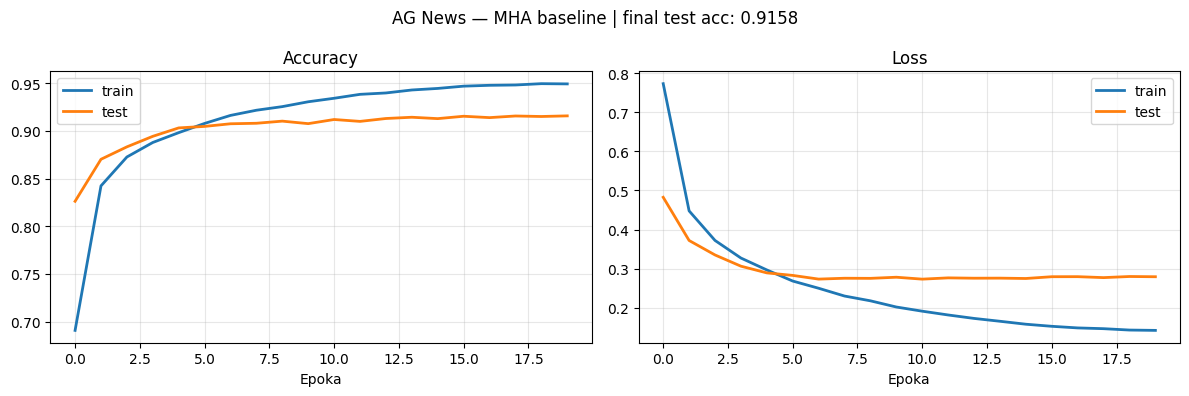


Best test acc: 0.9158
Final gap:     0.0335


In [11]:
# Szybki test — trening bez MLflow
set_seed(42)
train_loader, test_loader = get_loaders(max_length=64, batch_size=128)

model_test = TextClassifier(
    vocab_size=len(vocab),
    num_heads=8, num_groups=8,  # MHA baseline
    num_classes=NUM_CLASSES
).to(DEVICE)

optimizer = torch.optim.Adam(model_test.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

history = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}

for epoch in range(1, 21):
    t_loss, t_acc = train_epoch(model_test, train_loader, optimizer, criterion, epoch, 'MHA_test')
    v_loss, v_acc = evaluate(model_test, test_loader, criterion, f'eval e{epoch}')
    scheduler.step()
    history['train_acc'].append(t_acc)
    history['test_acc'].append(v_acc)
    history['train_loss'].append(t_loss)
    history['test_loss'].append(v_loss)
    print(f'Epoch {epoch:2d} | train={t_acc:.4f} | test={v_acc:.4f}')

# Wykres
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_acc'], label='train', linewidth=2)
axes[0].plot(history['test_acc'],  label='test',  linewidth=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoka')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_loss'], label='train', linewidth=2)
axes[1].plot(history['test_loss'],  label='test',  linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'AG News — MHA baseline | final test acc: {max(history["test_acc"]):.4f}')
plt.tight_layout()
plt.show()

print(f'\nBest test acc: {max(history["test_acc"]):.4f}')
print(f'Final gap:     {history["train_acc"][-1] - history["test_acc"][-1]:.4f}')

## 4. Eksperyment 1 — Wpływ liczby głowic H w MHA

Pytanie: czy na trudniejszym zadaniu (4 klasy) więcej głowic pomaga?
Każdy wariant: num_heads=H, num_groups=H (MHA).

In [12]:
SEEDS      = [42, 123, 777]
H_VALUES   = [1, 2, 4, 8]
results_h  = defaultdict(list)

for H in H_VALUES:
    print(f'\n===== MHA H={H} =====')
    for seed in SEEDS:
        result = run_experiment(
            run_name    = f'exp1_MHA_H{H}_seed{seed}',
            num_heads   = H,
            num_groups  = H,   # G=H → MHA
            seed        = seed,
            num_epochs  = 15,
            extra_params= {'experiment': 'exp1_MHA_heads', 'H': H}
        )
        results_h[H].append(result)

print('\n=== Eksperyment 1 zakończony ===')


===== MHA H=1 =====


[exp1_MHA_H1_seed42]: 100%|██████████| 15/15 [14:17<00:00, 57.14s/it, test=0.9097, train=0.9307]



→ exp1_MHA_H1_seed42 | best_acc=0.9099 | params=2,538,180 | train_time=13.5min | inf=12.27ms | mem=221.9MB



[exp1_MHA_H1_seed123]: 100%|██████████| 15/15 [19:18<00:00, 77.20s/it, test=0.9087, train=0.9317]



→ exp1_MHA_H1_seed123 | best_acc=0.9095 | params=2,538,180 | train_time=18.1min | inf=13.64ms | mem=221.9MB



...


→ exp1_MHA_H8_seed42 | best_acc=0.9097 | params=2,538,180 | train_time=35.5min | inf=36.72ms | mem=219.8MB



[exp1_MHA_H8_seed123]: 100%|██████████| 15/15 [53:14<00:00, 212.94s/it, test=0.9099, train=0.9378]



→ exp1_MHA_H8_seed123 | best_acc=0.9103 | params=2,538,180 | train_time=52.0min | inf=43.71ms | mem=220.5MB



[exp1_MHA_H8_seed777]: 100%|██████████| 15/15 [52:39<00:00, 210.61s/it, test=0.9139, train=0.9381]



→ exp1_MHA_H8_seed777 | best_acc=0.9147 | params=2,538,180 | train_time=51.7min | inf=38.58ms | mem=220.5MB


=== Eksperyment 1 zakończony ===



Wariant      Acc mean   Acc std  Params       Train time   Overfit gap
----------------------------------------------------------------------
MHA H=1      0.9107     0.0014    2,538,180     16.6min   0.0209
MHA H=2      0.9109     0.0015    2,538,180     27.4min   0.0226
MHA H=4      0.9111     0.0026    2,538,180     61.0min   0.0246
MHA H=8      0.9116     0.0022    2,538,180     46.4min   0.0268


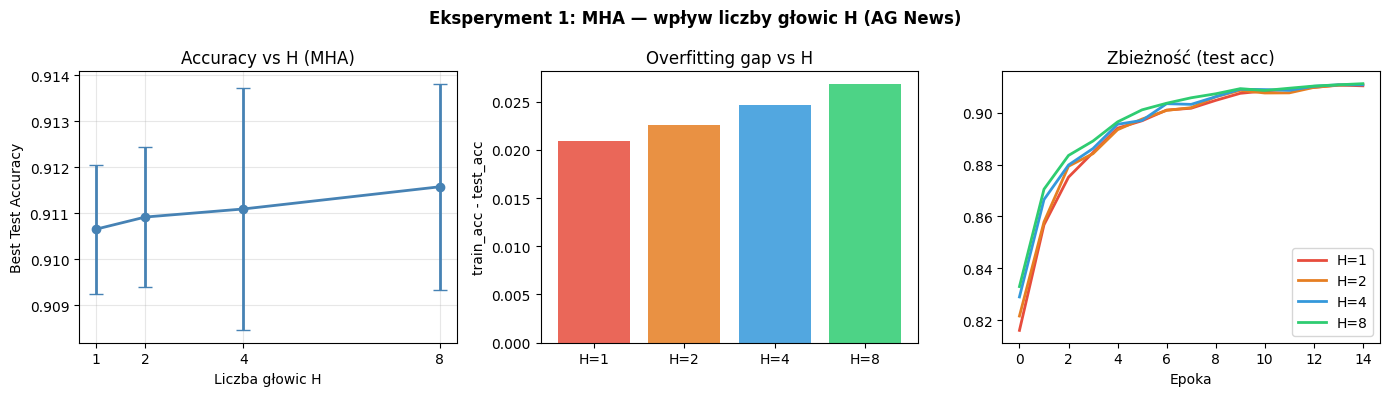

In [13]:
# Podsumowanie Eksperyment 1
print(f'\n{"Wariant":12} {"Acc mean":10} {"Acc std":8} {"Params":12} {"Train time":12} {"Overfit gap"}')
print('-' * 70)
for H in H_VALUES:
    accs  = [r['best_test_acc'] for r in results_h[H]]
    times = [r['total_train_time_s'] for r in results_h[H]]
    gaps  = [r['overfitting_gap'] for r in results_h[H]]
    p     = results_h[H][0]['num_params']
    print(f'MHA H={H:<6} {np.mean(accs):.4f}     {np.std(accs):.4f}   {p:10,}   {np.mean(times)/60:6.1f}min   {np.mean(gaps):.4f}')

# Wykres
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

# accuracy
ax = axes[0]
means = [np.mean([r['best_test_acc'] for r in results_h[H]]) for H in H_VALUES]
stds  = [np.std( [r['best_test_acc'] for r in results_h[H]]) for H in H_VALUES]
ax.errorbar(H_VALUES, means, yerr=stds, marker='o', linewidth=2, capsize=5, color='steelblue')
ax.set_xlabel('Liczba głowic H')
ax.set_ylabel('Best Test Accuracy')
ax.set_title('Accuracy vs H (MHA)')
ax.set_xticks(H_VALUES)
ax.grid(True, alpha=0.3)

# overfitting gap
ax = axes[1]
gaps = [np.mean([r['overfitting_gap'] for r in results_h[H]]) for H in H_VALUES]
ax.bar([f'H={H}' for H in H_VALUES], gaps, color=colors, alpha=0.85)
ax.set_title('Overfitting gap vs H')
ax.set_ylabel('train_acc - test_acc')

# krzywa zbieżności
ax = axes[2]
for H, c in zip(H_VALUES, colors):
    mean_hist = np.mean([r['history']['test_acc'] for r in results_h[H]], axis=0)
    ax.plot(mean_hist, label=f'H={H}', color=c, linewidth=2)
ax.set_title('Zbieżność (test acc)')
ax.set_xlabel('Epoka')
ax.legend()

plt.suptitle('Eksperyment 1: MHA — wpływ liczby głowic H (AG News)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('exp1_agnews_heads.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact('exp1_agnews_heads.png')
plt.show()

## 5. Eksperyment 2 — MQA vs GQA vs MHA

Pytanie: jak redukcja głowic K,V (G) wpływa na accuracy przy H=8?
G=1 (MQA), G=2, G=4, G=8 (MHA).

In [14]:
G_VALUES   = [1, 2, 4, 8]
results_g  = defaultdict(list)
labels_g   = {1: 'MQA (G=1)', 2: 'GQA (G=2)', 4: 'GQA (G=4)', 8: 'MHA (G=8)'}

for G in G_VALUES:
    label = labels_g[G]
    print(f'\n===== {label} =====')
    for seed in SEEDS:
        result = run_experiment(
            run_name    = f'exp2_{label.replace(" ","").replace("(","").replace(")","")}_seed{seed}',
            num_heads   = 8,   # H zawsze 8
            num_groups  = G,   # G się zmienia
            seed        = seed,
            num_epochs  = 15,
            extra_params= {'experiment': 'exp2_GQA_sweep', 'G': G, 'H': 8}
        )
        results_g[G].append(result)

print('\n=== Eksperyment 2 zakończony ===')


===== MQA (G=1) =====


[exp2_MQAG=1_seed42]: 100%|██████████| 15/15 [47:14<00:00, 188.98s/it, test=0.9091, train=0.9346]



→ exp2_MQAG=1_seed42 | best_acc=0.9091 | params=2,452,164 | train_time=45.6min | inf=36.31ms | mem=219.1MB



[exp2_MQAG=1_seed123]: 100%|██████████| 15/15 [47:06<00:00, 188.46s/it, test=0.9109, train=0.9339]



→ exp2_MQAG=1_seed123 | best_acc=0.9118 | params=2,452,164 | train_time=44.6min | inf=35.01ms | mem=219.1MB



...


→ exp2_MHAG=8_seed42 | best_acc=0.9097 | params=2,538,180 | train_time=27.0min | inf=24.48ms | mem=220.5MB



[exp2_MHAG=8_seed123]: 100%|██████████| 15/15 [28:09<00:00, 112.60s/it, test=0.9099, train=0.9378]



→ exp2_MHAG=8_seed123 | best_acc=0.9103 | params=2,538,180 | train_time=27.5min | inf=22.67ms | mem=220.5MB



[exp2_MHAG=8_seed777]: 100%|██████████| 15/15 [28:02<00:00, 112.18s/it, test=0.9139, train=0.9381]



→ exp2_MHAG=8_seed777 | best_acc=0.9147 | params=2,538,180 | train_time=27.6min | inf=22.79ms | mem=220.5MB


=== Eksperyment 2 zakończony ===



Wariant         Acc mean   Acc std  Params       Inf. time    Overfit gap
---------------------------------------------------------------------------
MQA (G=1)       0.9107     0.0012    2,452,164      35.38ms   0.0240
GQA (G=2)       0.9127     0.0016    2,464,452      34.63ms   0.0227
GQA (G=4)       0.9112     0.0019    2,489,028      30.04ms   0.0257
MHA (G=8)       0.9116     0.0022    2,538,180      23.31ms   0.0268


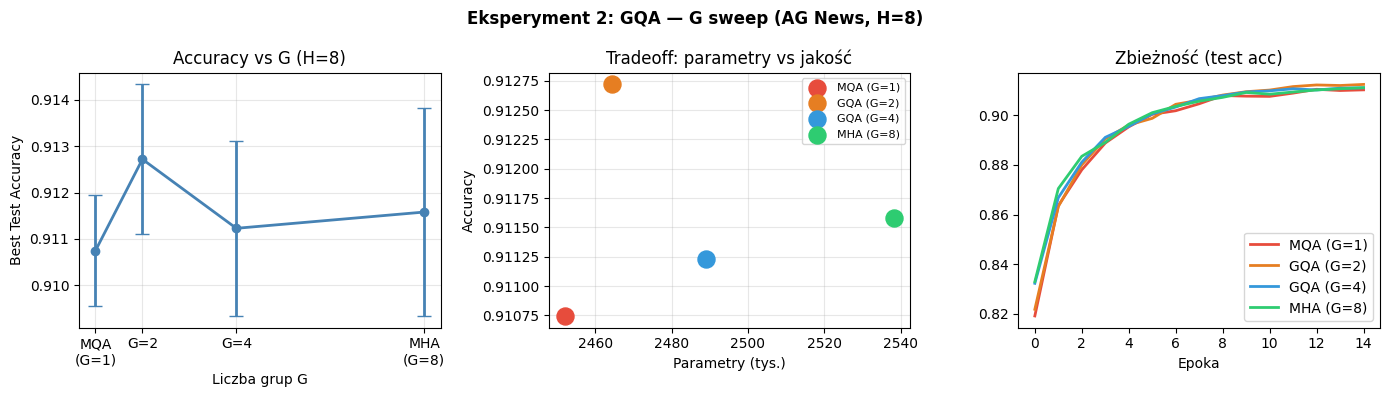


Modele zapisane w: /home/mikol/ai_studies/Deep-Neural-Networks-PWR/lab11/models
Pliki: ['exp4_Last_GQA_seed123_model.pt', 'exp4_All_MHA_seed123_model.pt', 'exp0_MHA_H8_seed777.pt', 'exp1_MQA_seed777_model.pt', 'exp2_GQAG=4_seed777.pt', 'exp2_MQAG=1_seed123.pt', 'exp1_MHA_H2_seed777.pt', 'exp1_MHA_H8_seed42.pt', 'exp1_GQA_G2_seed123_model.pt', 'exp1_MHA_H2_seed42.pt', 'exp4_All_GQA_seed123_model.pt', 'exp4_Last_GQA_seed42_model.pt', 'exp1_MHA_seed42_model.pt', 'exp2_MQAG=1_seed42.pt', 'exp0_MHA_H4_seed42.pt', 'exp1_MHA_seed123_model.pt', 'exp3_len64_GQA_G2_model.pt', 'exp4_First2_GQA_seed777_model.pt', 'exp3_len128_GQA_G4_model.pt', 'exp4_All_GQA_seed42_model.pt', 'exp1_MQA_seed123_model.pt', 'exp1_GQA_G4_seed123_model.pt', 'exp1_GQA_G2_seed42_model.pt', 'exp3_len512_GQA_G2_model.pt', 'exp1_MHA_H1_seed777.pt', 'exp4_All_GQA_seed777_model.pt', 'exp2_GQAG=2_seed123.pt', 'exp4_First_GQA_seed42_model.pt', 'exp0_MHA_H1_seed42.pt', 'exp4_Mid_GQA_seed777_model.pt', 'exp1_GQA_G4_seed777_model.

In [15]:
# Podsumowanie Eksperyment 2
print(f'\n{"Wariant":15} {"Acc mean":10} {"Acc std":8} {"Params":12} {"Inf. time":12} {"Overfit gap"}')
print('-' * 75)
for G in G_VALUES:
    accs  = [r['best_test_acc'] for r in results_g[G]]
    gaps  = [r['overfitting_gap'] for r in results_g[G]]
    inft  = [r['inference_time_ms'] for r in results_g[G]]
    p     = results_g[G][0]['num_params']
    print(f'{labels_g[G]:15} {np.mean(accs):.4f}     {np.std(accs):.4f}   {p:10,}   {np.mean(inft):8.2f}ms   {np.mean(gaps):.4f}')

# Wykres
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# accuracy vs G
ax = axes[0]
means = [np.mean([r['best_test_acc'] for r in results_g[G]]) for G in G_VALUES]
stds  = [np.std( [r['best_test_acc'] for r in results_g[G]]) for G in G_VALUES]
ax.errorbar(G_VALUES, means, yerr=stds, marker='o', linewidth=2, capsize=5, color='steelblue')
ax.set_xlabel('Liczba grup G')
ax.set_ylabel('Best Test Accuracy')
ax.set_title('Accuracy vs G (H=8)')
ax.set_xticks(G_VALUES)
ax.set_xticklabels(['MQA\n(G=1)', 'G=2', 'G=4', 'MHA\n(G=8)'])
ax.grid(True, alpha=0.3)

# tradeoff params vs accuracy
ax = axes[1]
for G, c in zip(G_VALUES, colors):
    acc = np.mean([r['best_test_acc'] for r in results_g[G]])
    p   = results_g[G][0]['num_params'] / 1000
    ax.scatter(p, acc, s=150, color=c, label=labels_g[G], zorder=5)
ax.set_xlabel('Parametry (tys.)')
ax.set_ylabel('Accuracy')
ax.set_title('Tradeoff: parametry vs jakość')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# krzywa zbieżności
ax = axes[2]
for G, c in zip(G_VALUES, colors):
    mean_hist = np.mean([r['history']['test_acc'] for r in results_g[G]], axis=0)
    ax.plot(mean_hist, label=labels_g[G], color=c, linewidth=2)
ax.set_title('Zbieżność (test acc)')
ax.set_xlabel('Epoka')
ax.legend()

plt.suptitle('Eksperyment 2: GQA — G sweep (AG News, H=8)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('exp2_agnews_gqa.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact('exp2_agnews_gqa.png')
plt.show()

# Porównanie IMDB vs AG News (jeśli masz wyniki z poprzedniego notebooka)
print('\nModele zapisane w:', os.path.abspath(MODELS_DIR))
print('Pliki:', os.listdir(MODELS_DIR))